# Test case A: 2D circle with arc remove

In [6]:
# setup imports
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram

In [8]:
# create the full circle:
n = 200
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
# (cos(θ), sin(θ)) for θ in [0, 2π/n, 4π/n, ..., 2π(n-1)/n]
full = np.stack([np.cos(theta), np.sin(theta)], axis=1)

# create a circle with a 60-degree arc removed:
mask = ~((theta > np.pi/2) & (theta < np.pi/2 + np.pi/3))
broken = full[mask]

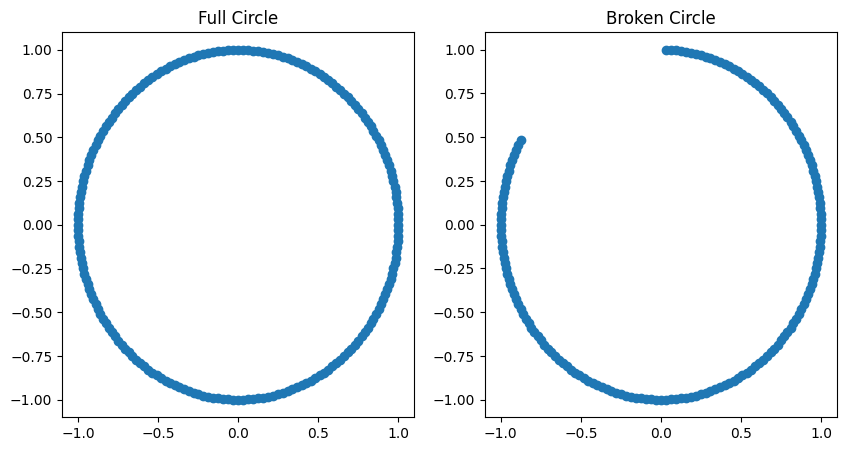

In [ ]:
# plot the two circles:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(full[:, 0], full[:, 1])
axes[0].set_title("Full Circle")
axes[1].scatter(broken[:, 0], broken[:, 1])
axes[1].set_title("Broken Circle")
plt.show()

In [ ]:
# calculate our persistence diagrams:
vr = VietorisRipsPersistence(homology_dimensions=[0, 1])
diag_full = vr.fit_transform(full[None, ...])
diag_broken = vr.fit_transform(broken[None, ...])

In [11]:
plot_diagram(diag_full[0]).show()

In [12]:
plot_diagram(diag_broken[0]).show()

# Intuition-building exercises

Each exercise has a **prediction** prompt. Write your guess before running the code cell — the goal is to calibrate your mental model of what persistence diagrams encode.

## Exercise 1: Gap size → H1 birth time

We take the unit circle and vary the removed arc: 30°, 60°, 90°, 120°.

**Predict before running:** As the gap gets larger, what happens to the H1 feature's birth time? Does it shift right (born later), shrink in persistence, or disappear entirely at some gap size?

**My prediction:** As the gap gets larger, the H1 feature's birth time should shift right and its persistence should decrease. I presume if the gap is greater than (maybe) 180°, we might not even detect an H1 feature.

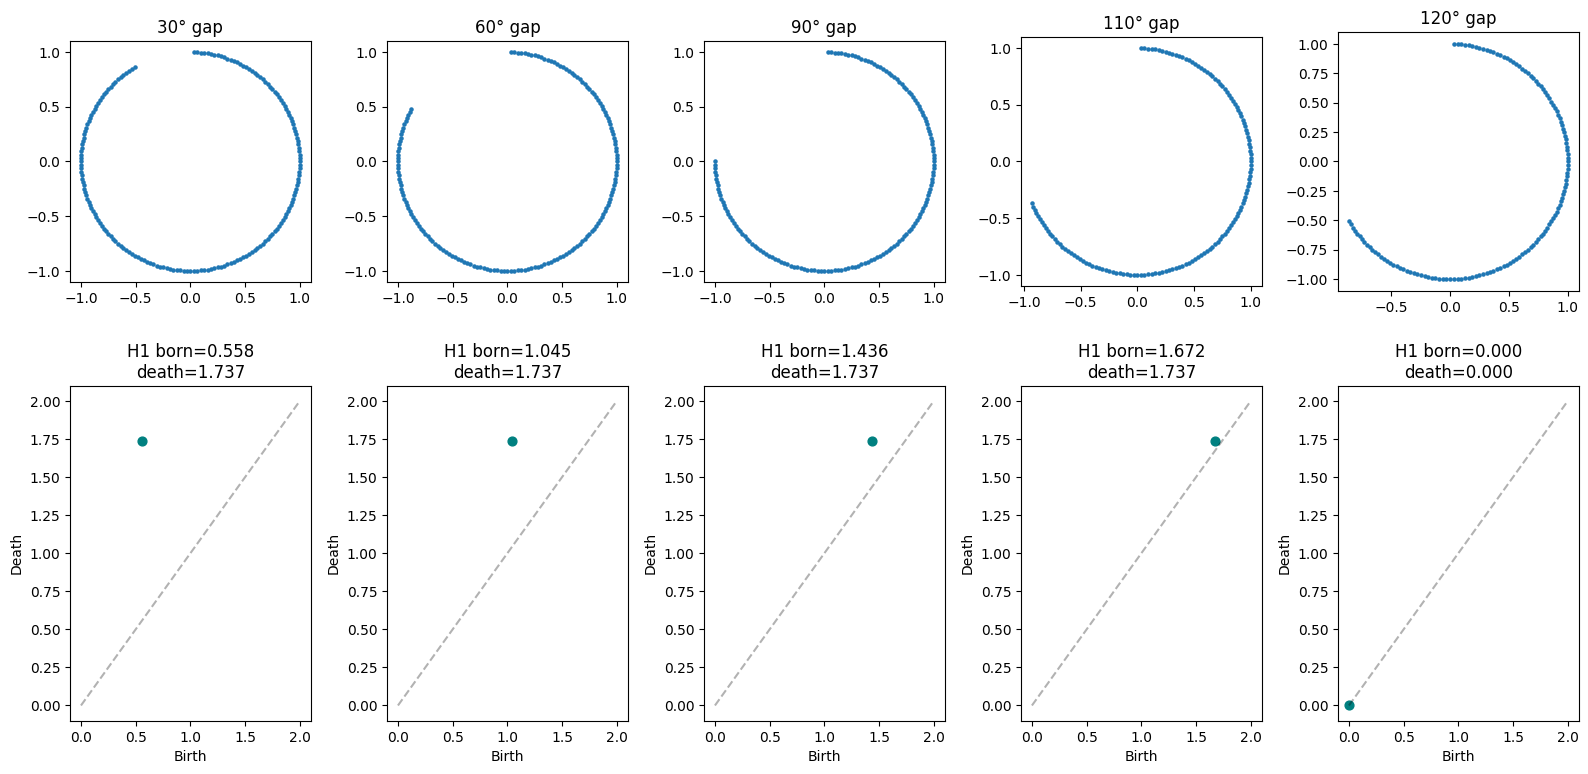

In [14]:
gaps_deg = [30, 60, 90, 110, 120]
fig, axes = plt.subplots(2, len(gaps_deg), figsize=(16, 8))

for i, gap in enumerate(gaps_deg):
    gap_rad = np.radians(gap)
    mask = ~((theta > np.pi/2) & (theta < np.pi/2 + gap_rad))
    pts = full[mask]

    # Plot point cloud
    axes[0, i].scatter(pts[:, 0], pts[:, 1], s=5)
    axes[0, i].set_title(f"{gap}° gap")
    axes[0, i].set_aspect("equal")

    # Compute persistence
    diag = vr.fit_transform(pts[None, ...])[0]

    # Plot H1 features only
    h1 = diag[diag[:, 2] == 1]
    if len(h1) > 0:
        persistence = h1[:, 1] - h1[:, 0]
        max_idx = persistence.argmax()
        axes[1, i].scatter(h1[:, 0], h1[:, 1], c="teal", s=40)
        axes[1, i].set_title(f"H1 born={h1[max_idx, 0]:.3f}\ndeath={h1[max_idx, 1]:.3f}")
    else:
        axes[1, i].set_title("No H1 features")

    # Diagonal reference
    lim = max(axes[1, i].get_xlim()[1], axes[1, i].get_ylim()[1])
    axes[1, i].plot([0, 2], [0, 2], "k--", alpha=0.3)
    axes[1, i].set_xlabel("Birth")
    axes[1, i].set_ylabel("Death")

plt.tight_layout()
plt.show()

## Exercise 2: Two clusters, varying separation

Two Gaussian blobs (100 pts each) in 2D with separation 10, 5, and 2.

**Predict before running:** The H0 diagram should show two components merging into one. At what point does the "second component" feature die? How does that death time relate to the cluster separation? What happens when separation=2 and the clusters overlap?

**My prediction:** We should see two H0 dots and the vertical distance between them is proportional to the separation. When separation=2 and the cluster overlap we should only see 1 H0 feature.

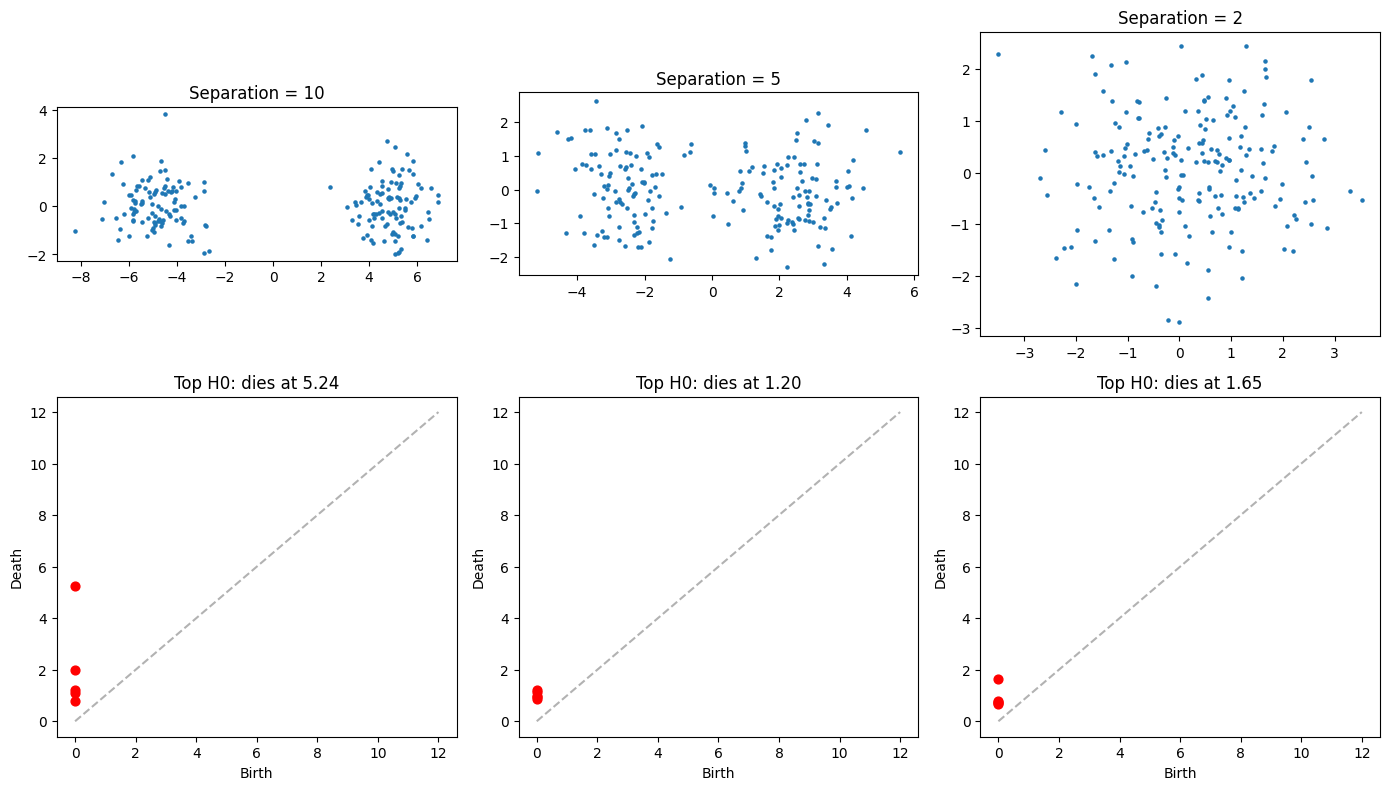

In [15]:
np.random.seed(42)
separations = [10, 5, 2]
fig, axes = plt.subplots(2, len(separations), figsize=(14, 8))

for i, sep in enumerate(separations):
    cluster_a = np.random.randn(100, 2) + np.array([sep/2, 0])
    cluster_b = np.random.randn(100, 2) - np.array([sep/2, 0])
    pts = np.vstack([cluster_a, cluster_b])

    axes[0, i].scatter(pts[:, 0], pts[:, 1], s=5)
    axes[0, i].set_title(f"Separation = {sep}")
    axes[0, i].set_aspect("equal")

    diag = vr.fit_transform(pts[None, ...])[0]

    # H0 features: find the most persistent one (the last component to merge)
    h0 = diag[diag[:, 2] == 0]
    persistence = h0[:, 1] - h0[:, 0]
    # Sort by persistence, show top few
    top_idx = persistence.argsort()[-5:][::-1]
    axes[1, i].scatter(h0[top_idx, 0], h0[top_idx, 1], c="red", s=40)
    axes[1, i].plot([0, 12], [0, 12], "k--", alpha=0.3)
    axes[1, i].set_xlabel("Birth")
    axes[1, i].set_ylabel("Death")
    most_persistent = h0[top_idx[0]]
    axes[1, i].set_title(f"Top H0: dies at {most_persistent[1]:.2f}")

plt.tight_layout()
plt.show()

## Exercise 3: Figure-8 (two tangent circles)

Two unit circles touching at the origin.

**Predict before running:** How many H1 features do you expect? Will they have the same birth/death times, or different? Why?

**My prediction:** Depending on how noisy the data is, I'd expect 1 H1 feature. But this is static data, so I think we should see 1 connected component and 2 H1 features with the same birth/death times because the circles have the same radius.

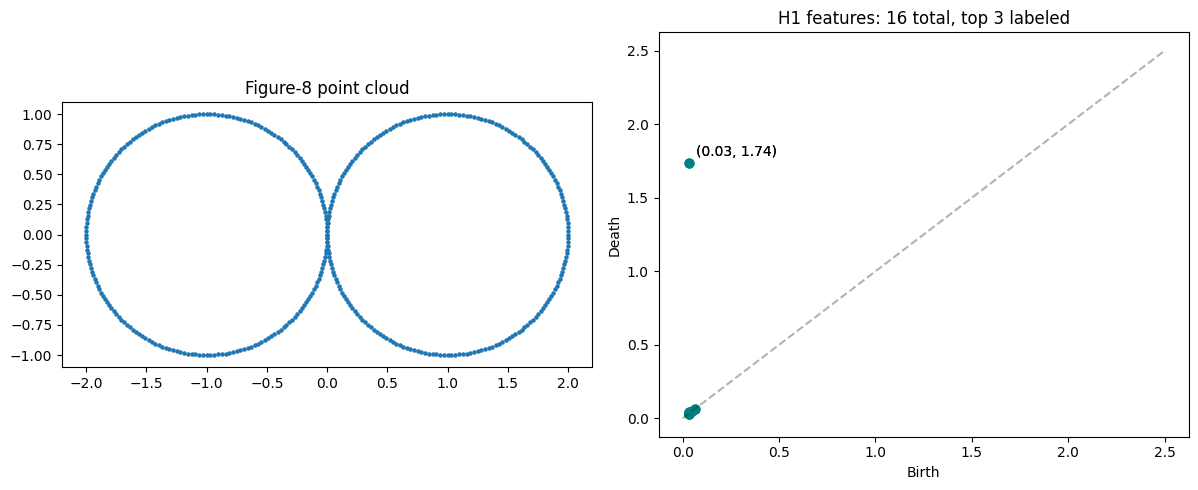

In [26]:
n = 200
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Left circle centered at (-1, 0)
left = np.stack([np.cos(theta) - 1, np.sin(theta)], axis=1)
# Right circle centered at (1, 0)
right = np.stack([np.cos(theta) + 1, np.sin(theta)], axis=1)
figure8 = np.vstack([left, right])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(figure8[:, 0], figure8[:, 1], s=5)
axes[0].set_aspect("equal")
axes[0].set_title("Figure-8 point cloud")

diag = vr.fit_transform(figure8[None, ...])[0]
h1 = diag[diag[:, 2] == 1]
persistence = h1[:, 1] - h1[:, 0]
top_idx = persistence.argsort()[-5:][::-1]

axes[1].scatter(h1[:, 0], h1[:, 1], c="teal", s=40)
axes[1].plot([0, 2.5], [0, 2.5], "k--", alpha=0.3)
axes[1].set_xlabel("Birth")
axes[1].set_ylabel("Death")
for j in range(min(2, len(top_idx))):
    b, d = h1[top_idx[j], 0], h1[top_idx[j], 1]
    axes[1].annotate(f"({b:.2f}, {d:.2f})", (b, d), textcoords="offset points", xytext=(5, 5))
axes[1].set_title(f"H1 features: {len(h1)} total, top {min(3, len(top_idx))} labeled")

plt.tight_layout()
plt.show()

## Exercise 4: Annulus (thick ring) vs thin circle

Sample 200 points from a thin circle (radius 1, no thickness) vs 200 points from a fat annulus (inner radius 0.7, outer radius 1.3).

**Predict before running:** Both have one loop (H1). Which has longer persistence — the thin circle or the fat annulus? Think about what "birth" and "death" depend on: point spacing (affects birth) and the width/fill of the ring (affects death).

**My prediction:** The annulus' H1 will have an earlier death because its radius is 0.7 < 1, the radius of the circle. I also suspect the persistence will be smaller because the thicker the annulus, the harder it will be to distinguish between it and a filled circle.

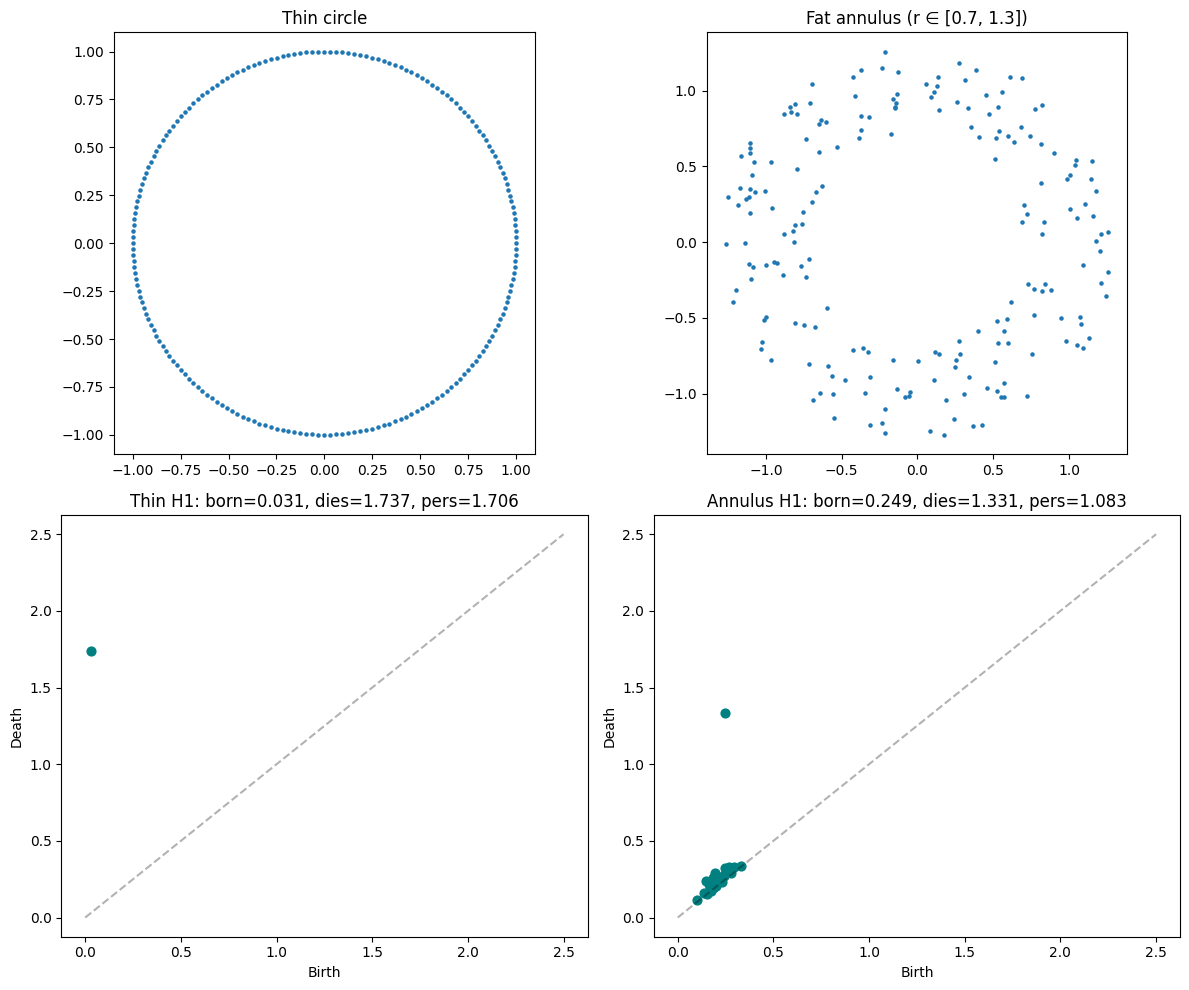

In [17]:
np.random.seed(7)
n = 200

# Thin circle
theta_thin = np.linspace(0, 2 * np.pi, n, endpoint=False)
thin_circle = np.stack([np.cos(theta_thin), np.sin(theta_thin)], axis=1)

# Fat annulus: uniform in polar between r=0.7 and r=1.3
theta_fat = np.random.uniform(0, 2 * np.pi, n)
r_fat = np.sqrt(np.random.uniform(0.7**2, 1.3**2, n))  # sqrt for uniform area sampling
annulus = np.stack([r_fat * np.cos(theta_fat), r_fat * np.sin(theta_fat)], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(thin_circle[:, 0], thin_circle[:, 1], s=5)
axes[0, 0].set_aspect("equal")
axes[0, 0].set_title("Thin circle")

axes[0, 1].scatter(annulus[:, 0], annulus[:, 1], s=5)
axes[0, 1].set_aspect("equal")
axes[0, 1].set_title("Fat annulus (r ∈ [0.7, 1.3])")

for idx, (pts, label) in enumerate([(thin_circle, "Thin"), (annulus, "Annulus")]):
    diag = vr.fit_transform(pts[None, ...])[0]
    h1 = diag[diag[:, 2] == 1]
    persistence = h1[:, 1] - h1[:, 0]
    max_i = persistence.argmax()
    axes[1, idx].scatter(h1[:, 0], h1[:, 1], c="teal", s=40)
    axes[1, idx].plot([0, 2.5], [0, 2.5], "k--", alpha=0.3)
    axes[1, idx].set_xlabel("Birth")
    axes[1, idx].set_ylabel("Death")
    b, d = h1[max_i, 0], h1[max_i, 1]
    axes[1, idx].set_title(f"{label} H1: born={b:.3f}, dies={d:.3f}, pers={d-b:.3f}")

plt.tight_layout()
plt.show()

## Exercise 5: Random noise baseline

200 points uniformly distributed in a unit square. No structure.

**Predict before running:** Will there be any H1 features? If so, will they be persistent (far from diagonal) or short-lived (hugging the diagonal)? This is your "null hypothesis" — what does a persistence diagram look like when there's *nothing* to find?

**My prediction:** I expect to see a few connected components, coalescing into one connected component. If there are H1 features, they'll be short-lived.

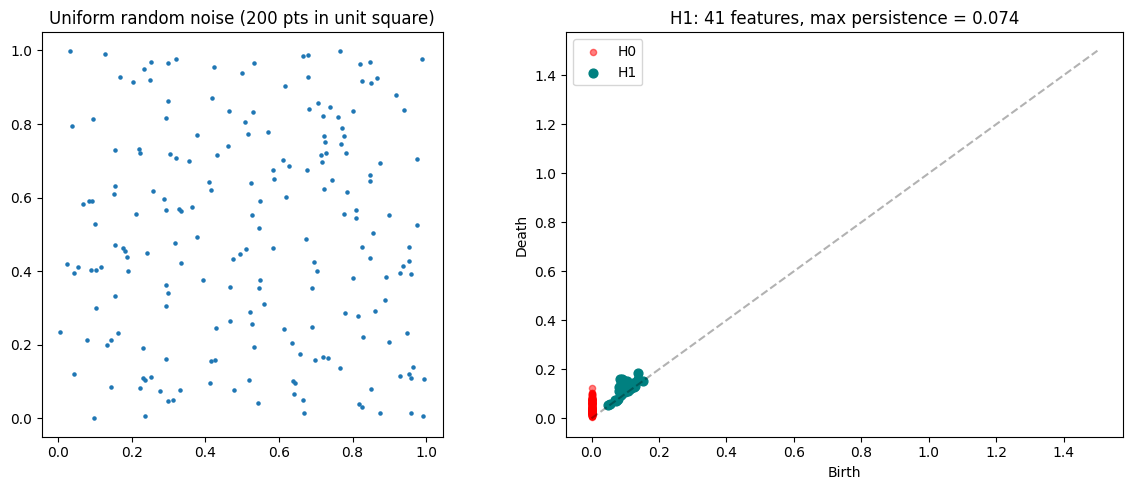

In [18]:
np.random.seed(99)
noise = np.random.uniform(0, 1, size=(200, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(noise[:, 0], noise[:, 1], s=5)
axes[0].set_aspect("equal")
axes[0].set_title("Uniform random noise (200 pts in unit square)")

diag = vr.fit_transform(noise[None, ...])[0]
h1 = diag[diag[:, 2] == 1]
h0 = diag[diag[:, 2] == 0]

axes[1].scatter(h0[:, 0], h0[:, 1], c="red", s=20, alpha=0.5, label="H0")
axes[1].scatter(h1[:, 0], h1[:, 1], c="teal", s=40, label="H1")
axes[1].plot([0, 1.5], [0, 1.5], "k--", alpha=0.3)
axes[1].set_xlabel("Birth")
axes[1].set_ylabel("Death")
axes[1].legend()

if len(h1) > 0:
    persistence = h1[:, 1] - h1[:, 0]
    axes[1].set_title(f"H1: {len(h1)} features, max persistence = {persistence.max():.3f}")
else:
    axes[1].set_title("No H1 features")

plt.tight_layout()
plt.show()

## Debrief

After running all five exercises, note:

1. **Exercise 1:** H1 birth time _increases_ as gap size increases. The persistence (death − birth) _decreases_.
2. **Exercise 2:** H0 death time tracks the _separation_ between clusters.
3. **Exercise 3:** Two loops → _2_ H1 features. They have _same_ birth/death because _they have the same radii_.
4. **Exercise 4:** The thin circle has _greater_ persistence than the annulus because _don't know_.
5. **Exercise 5:** Random noise produces H1 features that are _short-lived_ (persistent / short-lived). This means any "real" signal needs persistence greater than _1_ to be distinguishable from noise.

**Key takeaway for the real experiment:** When we ablate a class from CLIP embeddings, we're looking for a change in persistence that exceeds the noise floor established by Exercise 5's pattern (many short-lived features near the diagonal).

## Test Case B: 2 clusters

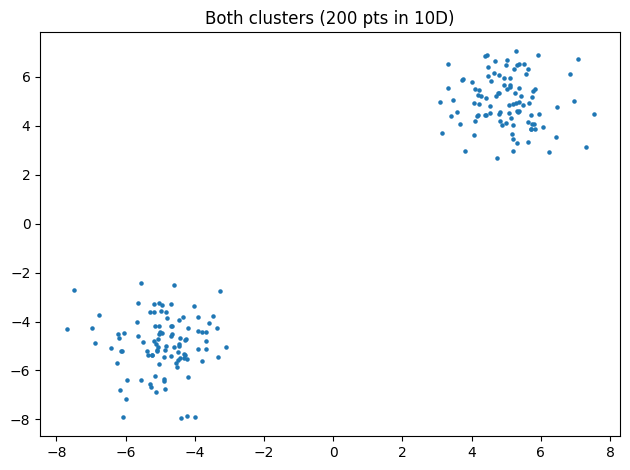

In [ ]:
np.random.seed(42)
cluster_a = np.random.randn(100, 10) + np.array([5]*10)
cluster_b = np.random.randn(100, 10) - np.array([5]*10)
both = np.vstack([cluster_a, cluster_b])
only_a = cluster_a

diag_both = vr.fit_transform(both[None, ...])
diag_a = vr.fit_transform(only_a[None, ...])

plt.scatter(both[:, 0], both[:, 1], s=5)
plt.title("Both clusters (200 pts in 10D)")
plt.tight_layout()
plt.show()


We see a whole bunch of noise along the diagonal because the `H1` feature isn't actually persistent. And, as expected, at a large enough scale, the two clusters merge into one component. Hence the persistent `H0` feature. But more importantly: the gap between the top 2 `H0` features indicates a "real" separation.

In [31]:
plot_both.show()

Demonstrating this idea with 3 distinct clusters, shows 2 distinct `H0` features:

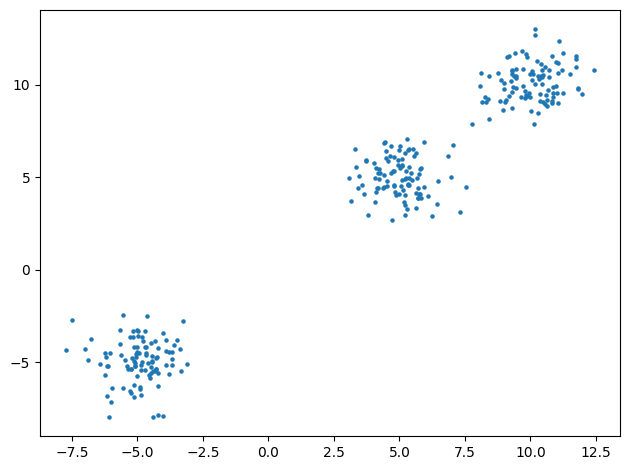

In [37]:
np.random.seed(42)
cluster_a = np.random.randn(100, 10) + np.array([5]*10)
cluster_b = np.random.randn(100, 10) - np.array([5]*10)
cluster_c = np.random.randn(100, 10) + np.array([10]*10)
both = np.vstack([cluster_a, cluster_b, cluster_c])

diag_both = vr.fit_transform(both[None, ...])

plt.scatter(both[:, 0], both[:, 1], s=5)
plt.tight_layout()
plt.show()

plot_diagram(diag_both[0]).show()